In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))


from src.safe_routing import*
from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit

In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')

In [3]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [3]:
with open(r'saves\partitioned_nodes_141.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [9]:
import src.network_plotting, importlib

importlib.reload(src.safe_routing)
from src.safe_routing import*

In [10]:
g = communication_graph_from_df(df, entity_names, keep_outsiders=False, spanning_tree=True)
entity_names = list(g.nodes)
len(g), len(entity_names)

(13, 13)

Conditioning number:  20.88493483915417 
Determinant of F^T*F:  0.5567601886737239


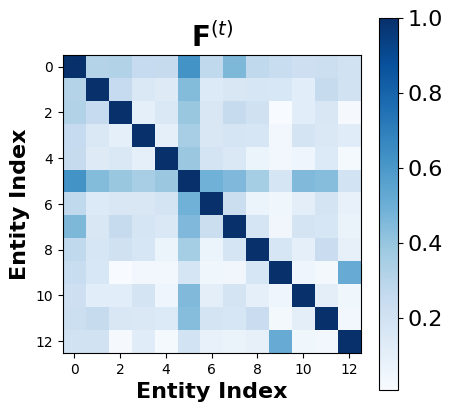

In [5]:
cu = ConnectivityUnit()
cu.read_flows(df, conn_param='NPR', entity_names=entity_names,
             window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')

cu.fit_graph_model(method = 'cov') # cov
cu.plot_f(labels=True)

In [6]:
from src.analyze_cic_ids import get_risk_mat_from_df

risk_mat, labels, labels_count, _, _, all_cov = get_risk_mat_from_df(df, entity_names=entity_names, t_graph=90, sync_window_size=1.2,
                                                                    return_cov=True)
risk_mean, risk_cov = risk_mat[-1,:], all_cov[-1]

with open(r'saves\risks_13.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump((risk_mean, risk_cov), handle, protocol=pickle.HIGHEST_PROTOCOL)


1
Current time and samples shape:  2017-04-07 01:02:00 (75, 13)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 13)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 13)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 13)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 13)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 13)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 13)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 13)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 13)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 13)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 13)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 13)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 13)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 13)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 13)
16
Current time and samples shape:

127
Current time and samples shape:  2017-04-07 09:05:00 (75, 13)
128
Current time and samples shape:  2017-04-07 09:07:00 (75, 13)
129
Current time and samples shape:  2017-04-07 09:09:00 (75, 13)
130
Current time and samples shape:  2017-04-07 09:11:00 (75, 13)
131
Current time and samples shape:  2017-04-07 09:13:00 (75, 13)
132
Current time and samples shape:  2017-04-07 09:15:00 (75, 13)
133
Current time and samples shape:  2017-04-07 09:17:00 (75, 13)
134
Current time and samples shape:  2017-04-07 09:19:00 (75, 13)
135
Current time and samples shape:  2017-04-07 09:21:00 (75, 13)
136
Current time and samples shape:  2017-04-07 09:23:00 (75, 13)
137
Current time and samples shape:  2017-04-07 09:25:00 (75, 13)
138
Current time and samples shape:  2017-04-07 09:27:00 (75, 13)
139
Current time and samples shape:  2017-04-07 09:29:00 (75, 13)
140
Current time and samples shape:  2017-04-07 09:31:00 (75, 13)
141
Current time and samples shape:  2017-04-07 09:33:00 (75, 13)
142
Curren

In [25]:
with open(r'saves\risks_141.pickle', 'rb') as handle:
    risk_mean, risk_cov = pickle.load(handle) 

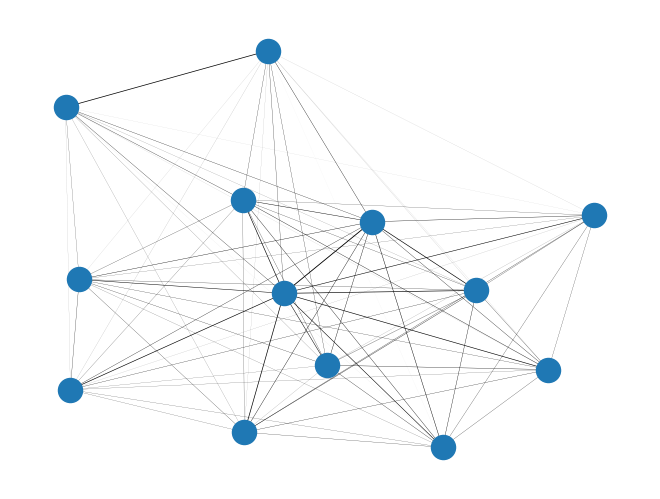

In [7]:
g_f = nx.from_numpy_array(cu.F - np.diag(np.diag(cu.F)))
nx.relabel_nodes(g_f, {i:name for i, name in enumerate(entity_names)}, copy=False)
pos_f = nx.spring_layout(g_f, seed=28)
widths = [g_f[u][v]['weight'] for u,v in g_f.edges]
nx.draw(g_f, pos=pos_f, width=widths, with_labels=False)

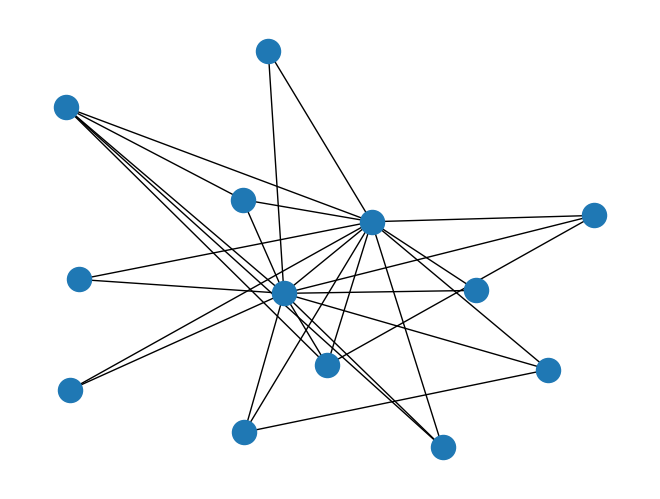

In [8]:
pos = nx.spring_layout(g)
nx.draw(g, pos=pos_f, with_labels=False)

In [12]:
import src.network_plotting, importlib

importlib.reload(src.network_plotting)
from src.network_plotting import*

In [13]:
pos_f, risk_mean, risk_cov = normalize_coordinates(pos_f, risk_mean, risk_cov)
np.max(list(pos_f.values()))

1.4088850013092986

In [14]:
np.max(risk_mean)

2.0

In [15]:
pos_dict = {name: pos_f[name].tolist() for name in entity_names}
edges_list = list(g.edges)
risk_mean_dict = {name: val.tolist() for name, val in zip(entity_names, risk_mean)}
risk_cov_list = risk_cov.tolist()
g_f_adj = nx.adjacency_matrix(g_f).todense().tolist()

In [16]:
pos2json(r"../src/network_rendering/saves/net_data1", pos = pos_dict, topologyEdges=edges_list, risk_mean=risk_mean_dict,
         risk_cov = risk_cov_list, funcEdges=g_f_adj)